In [28]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("COVID Analytics Pipeline") \
    .getOrCreate()

In [29]:
base_path = "data/"

files = {
    "full_grouped": base_path + "full_grouped.csv",
    "covid_clean": base_path + "covid_19_clean_complete.csv",
    "country_latest": base_path + "country_wise_latest.csv",
    "day_wise": base_path + "day_wise.csv",
    "usa_county": base_path + "usa_county_wise.csv",
    "worldometer": base_path + "worldometer_data.csv"
}

In [30]:
df_full_grouped = spark.read.csv(files["full_grouped"], header=True, inferSchema=True)

df_covid_clean = spark.read.csv(files["covid_clean"], header=True, inferSchema=True)

df_country_latest = spark.read.csv(files["country_latest"], header=True, inferSchema=True)

df_day_wise = spark.read.csv(files["day_wise"], header=True, inferSchema=True)

df_usa_county = spark.read.csv(files["usa_county"], header=True, inferSchema=True)

df_worldometer = spark.read.csv(files["worldometer"], header=True, inferSchema=True)

In [31]:
print("\n FULL GROUPED SCHEMA")
df_full_grouped.printSchema()


 FULL GROUPED SCHEMA
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [32]:
print("\n COVID CLEAN SCHEMA")
df_covid_clean.printSchema()


 COVID CLEAN SCHEMA
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [33]:
print("\n COUNTRY LATEST SCHEMA")
df_country_latest.printSchema()


 COUNTRY LATEST SCHEMA
root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: string (nullable = true)
 |-- Confirmed last week: integer (nullable = true)
 |-- 1 week change: integer (nullable = true)
 |-- 1 week % increase: double (nullable = true)
 |-- WHO Region: string (nullable = true)



In [34]:
print("\n DAY WISE SCHEMA")
df_day_wise.printSchema()


 DAY WISE SCHEMA
root
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: double (nullable = true)
 |-- No. of countries: integer (nullable = true)



In [35]:
print("\n USA COUNTY SCHEMA")
df_usa_county.printSchema()


 USA COUNTY SCHEMA
root
 |-- UID: integer (nullable = true)
 |-- iso2: string (nullable = true)
 |-- iso3: string (nullable = true)
 |-- code3: integer (nullable = true)
 |-- FIPS: double (nullable = true)
 |-- Admin2: string (nullable = true)
 |-- Province_State: string (nullable = true)
 |-- Country_Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long_: double (nullable = true)
 |-- Combined_Key: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)



In [36]:
print("\n WORLDOMETER SCHEMA")
df_worldometer.printSchema()


 WORLDOMETER SCHEMA
root
 |-- Country/Region: string (nullable = true)
 |-- Continent: string (nullable = true)
 |-- Population: integer (nullable = true)
 |-- TotalCases: integer (nullable = true)
 |-- NewCases: integer (nullable = true)
 |-- TotalDeaths: integer (nullable = true)
 |-- NewDeaths: integer (nullable = true)
 |-- TotalRecovered: integer (nullable = true)
 |-- NewRecovered: integer (nullable = true)
 |-- ActiveCases: integer (nullable = true)
 |-- Serious,Critical: integer (nullable = true)
 |-- Tot Cases/1M pop: integer (nullable = true)
 |-- Deaths/1M pop: double (nullable = true)
 |-- TotalTests: integer (nullable = true)
 |-- Tests/1M pop: integer (nullable = true)
 |-- WHO Region: string (nullable = true)



In [37]:
print("\n ROW COUNTS")

print("Full Grouped:", df_full_grouped.count())
print("Covid Clean:", df_covid_clean.count())
print("Country Latest:", df_country_latest.count())
print("Day Wise:", df_day_wise.count())
print("USA County:", df_usa_county.count())
print("Worldometer:", df_worldometer.count())


 ROW COUNTS
Full Grouped: 35156
Covid Clean: 49068
Country Latest: 187
Day Wise: 188
USA County: 627920
Worldometer: 209


### Data Cleaning

#### Handle missing province/state values

In [38]:
from pyspark.sql.functions import col, when

In [39]:
(
    df_covid_clean
    .filter(col("Province/State").isNull())
    .show(5)
)

+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|Province/State|Country/Region|     Lat|     Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------+--------+---------+----------+---------+------+---------+------+--------------------+
|          NULL|   Afghanistan|33.93911|67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|       Albania| 41.1533|  20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|       Algeria| 28.0339|   1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|       Andorra| 42.5063|   1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|        Angola|-11.2027|  17.8739|2020-01-22|        0|     0|        0|     0|              Africa|
+--------------+--------------+--------+---------+----------+---

In [40]:
null_count = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .count()
)

print("Total NULL values in Province/State:", null_count)

Total NULL values in Province/State: 34404


In [41]:
df_null_country = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .groupBy("Country/Region")
    .count()
    .orderBy(col("count").desc())
)

df_null_country.show()

+--------------+-----+
|Country/Region|count|
+--------------+-----+
|          Chad|  188|
|      Paraguay|  188|
|        Russia|  188|
|         Yemen|  188|
|       Senegal|  188|
|    Cabo Verde|  188|
|        Sweden|  188|
|        Guyana|  188|
|       Eritrea|  188|
|   Philippines|  188|
|         Burma|  188|
|      Djibouti|  188|
|      Malaysia|  188|
|     Singapore|  188|
|          Fiji|  188|
|        Turkey|  188|
|        Malawi|  188|
|Western Sahara|  188|
|          Iraq|  188|
|       Germany|  188|
+--------------+-----+
only showing top 20 rows


In [42]:
df_covid_clean = (
    df_covid_clean
    .fillna({"Province/State": "Unknown"})
)

In [43]:
df_covid_clean.show()

+--------------------+-------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|      Province/State|     Country/Region|      Lat|      Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------------+-------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|             Unknown|        Afghanistan| 33.93911| 67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|             Unknown|            Albania|  41.1533|   20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|             Unknown|            Algeria|  28.0339|    1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|             Unknown|            Andorra|  42.5063|    1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|             Unknown|             Angola| -11.2027|   17.8739|2020-01-22|        0|     0

In [44]:
remaining_nulls = (
    df_covid_clean
    .filter(col("Province/State").isNull())
    .count()
)

print("Remaining NULL values:", remaining_nulls)

Remaining NULL values: 0


#### Standardize country names

In [45]:
(
    df_full_grouped
    .select("Country/Region")
    .distinct()
    .show(100, truncate=False)
)

+------------------------+
|Country/Region          |
+------------------------+
|Chad                    |
|Paraguay                |
|Russia                  |
|Yemen                   |
|Senegal                 |
|Cabo Verde              |
|Sweden                  |
|Guyana                  |
|Burma                   |
|Eritrea                 |
|Philippines             |
|Djibouti                |
|Malaysia                |
|Singapore               |
|Fiji                    |
|Turkey                  |
|Malawi                  |
|Western Sahara          |
|Iraq                    |
|Germany                 |
|Comoros                 |
|Afghanistan             |
|Cambodia                |
|Jordan                  |
|Maldives                |
|Rwanda                  |
|Sudan                   |
|France                  |
|Greece                  |
|Kosovo                  |
|Sri Lanka               |
|Dominica                |
|Algeria                 |
|Equatorial Guinea       |
|

In [46]:
# Defining a function to standardize country names
def standardize_countries(df):
    return df.withColumn(
        "Country/Region",
        when(col("Country/Region") == "US", "USA")
        .when(col("Country/Region") == "S. Korea", "South Korea")
        .otherwise(col("Country/Region"))
    )

In [47]:
# Applying the standardization to the relevant DataFrames
df_full_grouped = standardize_countries(df_full_grouped)
df_country_latest = standardize_countries(df_country_latest)
df_worldometer = standardize_countries(df_worldometer)

In [48]:
print("Verification in full_grouped (Should be USA and South Korea):")
df_full_grouped.filter(col("Country/Region").isin("USA", "US", "South Korea", "S. Korea")) \
    .select("Country/Region").distinct().show()

Verification in full_grouped (Should be USA and South Korea):
+--------------+
|Country/Region|
+--------------+
|           USA|
|   South Korea|
+--------------+



In [49]:
print("Verification in worldometer (Should be USA and South Korea):")
df_worldometer.filter(col("Country/Region").isin("USA", "US", "South Korea", "S. Korea")) \
    .select("Country/Region").distinct().show()

Verification in worldometer (Should be USA and South Korea):
+--------------+
|Country/Region|
+--------------+
|           USA|
|   South Korea|
+--------------+



#### Remove duplicate rows

In [50]:
# Count rows before removing duplicates to see if any exist
count_before = df_full_grouped.count()
print(f"Rows before dropping duplicates: {count_before}")

# Drop duplicates based on 'Country/Region' and 'Date'
df_full_grouped = df_full_grouped.dropDuplicates(["Country/Region", "Date"])

# Count rows after removing duplicates
count_after = df_full_grouped.count()
print(f"Rows after dropping duplicates: {count_after}")

# Print how many duplicates were found and removed
duplicates_removed = count_before - count_after
print(f"Total duplicates removed: {duplicates_removed}")

Rows before dropping duplicates: 35156
Rows after dropping duplicates: 35156
Total duplicates removed: 0


In [53]:
import matplotlib.pyplot as plt

#### Top 10 Countries by Total Confirmed Cases

In [55]:
# Getting Top 10 Countries by Total Confirmed Cases
top_10_confirmed = (df_country_latest
    .select("Country/Region", "Confirmed")
    .orderBy(col("Confirmed").desc())
    .limit(10))

In [56]:
print("Top 10 Countries by Total Confirmed Cases:")
top_10_confirmed.show()

Top 10 Countries by Total Confirmed Cases:
+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|           USA|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



In [58]:
# Converting the PySpark DataFrame to a Pandas DataFrame for plotting
top_10_pd = top_10_confirmed.toPandas()

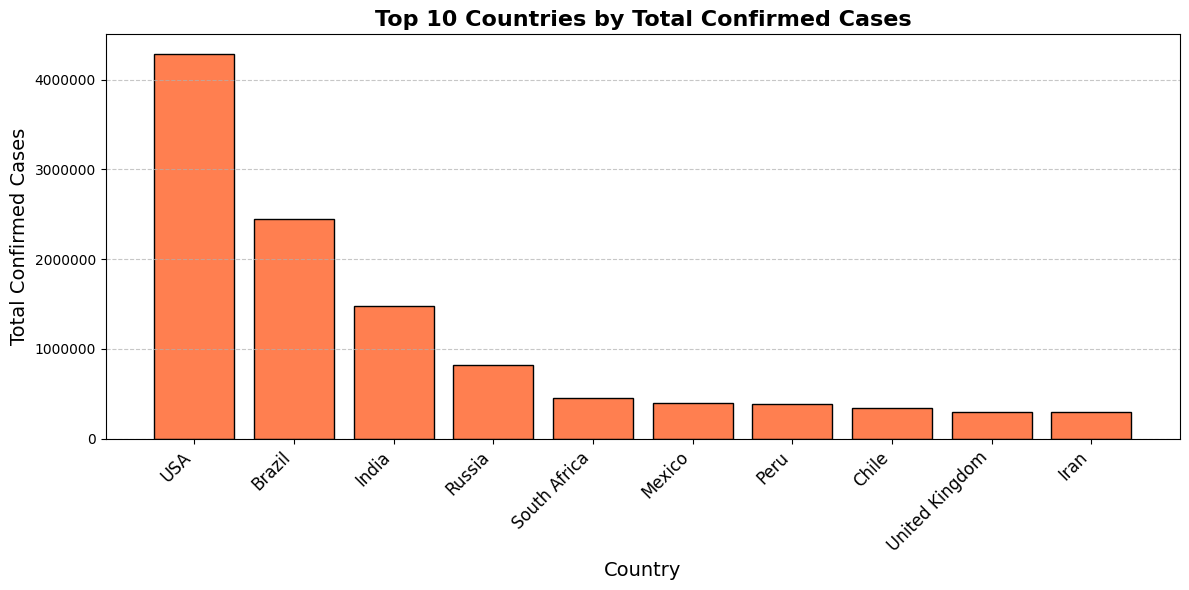

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(top_10_pd["Country/Region"], top_10_pd["Confirmed"], color='coral', edgecolor='black')

plt.title("Top 10 Countries by Total Confirmed Cases", fontsize=16, fontweight='bold')
plt.xlabel("Country", fontsize=14)
plt.ylabel("Total Confirmed Cases", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Top 10 Countries by Death Rate

In [63]:
# Getting Top 10 Countries by Death Rate (Deaths / 100 Cases)
top_10_death_rate = (df_country_latest
    .select("Country/Region", "Deaths / 100 Cases")
    .orderBy(col("Deaths / 100 Cases").desc())
    .limit(10))

In [64]:
print("Top 10 Countries by Death Rate (Deaths / 100 Cases):")
top_10_death_rate.show()

Top 10 Countries by Death Rate (Deaths / 100 Cases):
+--------------+------------------+
|Country/Region|Deaths / 100 Cases|
+--------------+------------------+
|         Yemen|             28.56|
|United Kingdom|             15.19|
|       Belgium|             14.79|
|         Italy|             14.26|
|        France|             13.71|
|       Hungary|              13.4|
|   Netherlands|             11.53|
|        Mexico|             11.13|
|         Spain|             10.44|
|Western Sahara|              10.0|
+--------------+------------------+



In [65]:
top_10_death_pd = top_10_death_rate.toPandas()

In [66]:
top_10_death_pd = top_10_death_pd.sort_values(by="Deaths / 100 Cases", ascending=True)

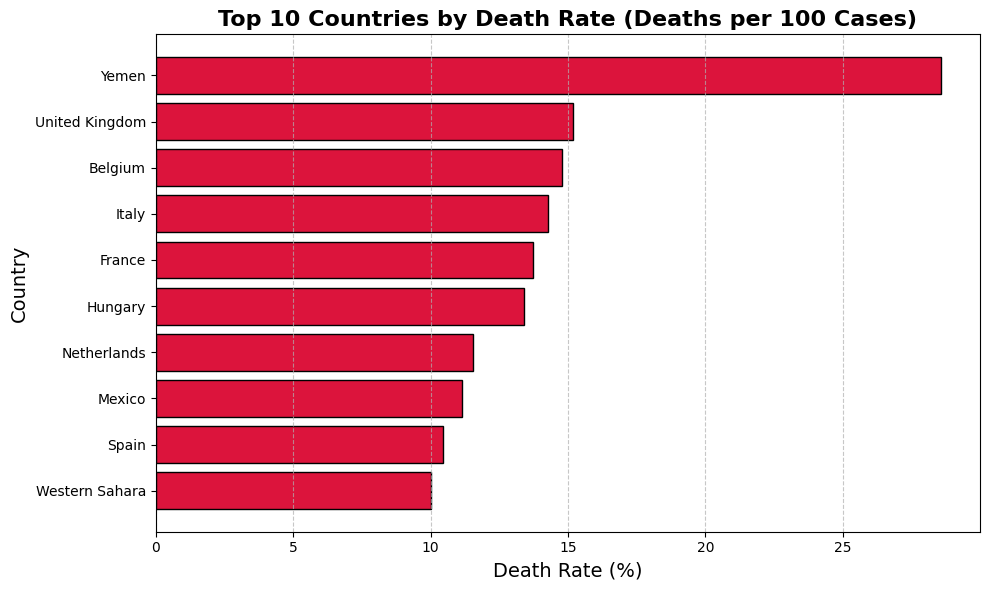

In [67]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_death_pd["Country/Region"], top_10_death_pd["Deaths / 100 Cases"], color='crimson', edgecolor='black')

plt.title("Top 10 Countries by Death Rate (Deaths per 100 Cases)", fontsize=16, fontweight='bold')
plt.xlabel("Death Rate (%)", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### WHO Region wise total cases

In [68]:
from pyspark.sql.functions import sum as _sum, max as _max
import pandas as pd

In [69]:
# Finding the latest date in the dataset
latest_date = df_full_grouped.select(_max("Date")).collect()[0][0]
print(f"Aggregating data for the latest date: {latest_date}")

Aggregating data for the latest date: 2020-07-27


In [70]:
# Filter for the latest date, then group by WHO Region and aggregate
who_region_totals = (df_full_grouped
    .filter(col("Date") == latest_date)
    .groupBy("WHO Region")
    .agg(
        _sum("Confirmed").alias("Total Confirmed"),
        _sum("Deaths").alias("Total Deaths"),
        _sum("Recovered").alias("Total Recovered")
    )
    .orderBy(col("Total Confirmed").desc()))

In [71]:
# Show the output table
print("WHO Region-wise Total Cases:")
who_region_totals.show()

WHO Region-wise Total Cases:
+--------------------+---------------+------------+---------------+
|          WHO Region|Total Confirmed|Total Deaths|Total Recovered|
+--------------------+---------------+------------+---------------+
|            Americas|        8839286|      342732|        4468616|
|              Europe|        3299523|      211144|        1993723|
|     South-East Asia|        1835297|       41349|        1156933|
|Eastern Mediterra...|        1490744|       38339|        1201400|
|              Africa|         723207|       12223|         440645|
|     Western Pacific|         292428|        8249|         206770|
+--------------------+---------------+------------+---------------+



In [72]:
who_pd = who_region_totals.toPandas()

In [73]:
# Ensuring WHO Region is the index for easier stacked bar plotting
who_pd.set_index("WHO Region", inplace=True)

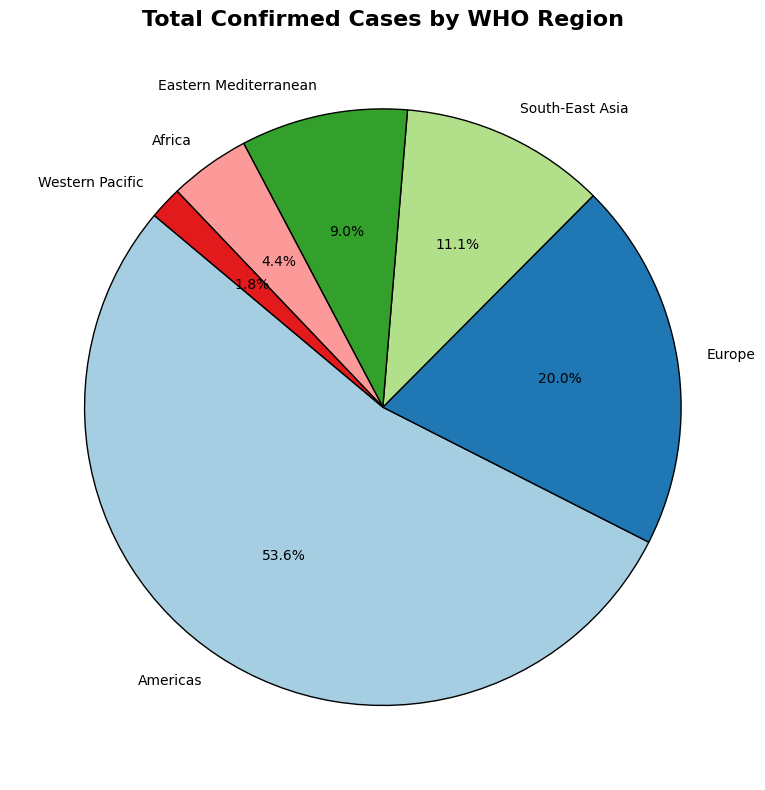

In [74]:
plt.figure(figsize=(8, 8))
plt.pie(who_pd["Total Confirmed"], labels=who_pd.index, autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Paired.colors, wedgeprops={'edgecolor': 'black'})
plt.title("Total Confirmed Cases by WHO Region", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [75]:
# Active = Confirmed - (Deaths + Recovered)
who_pd["Active Cases"] = who_pd["Total Confirmed"] - (who_pd["Total Deaths"] + who_pd["Total Recovered"])

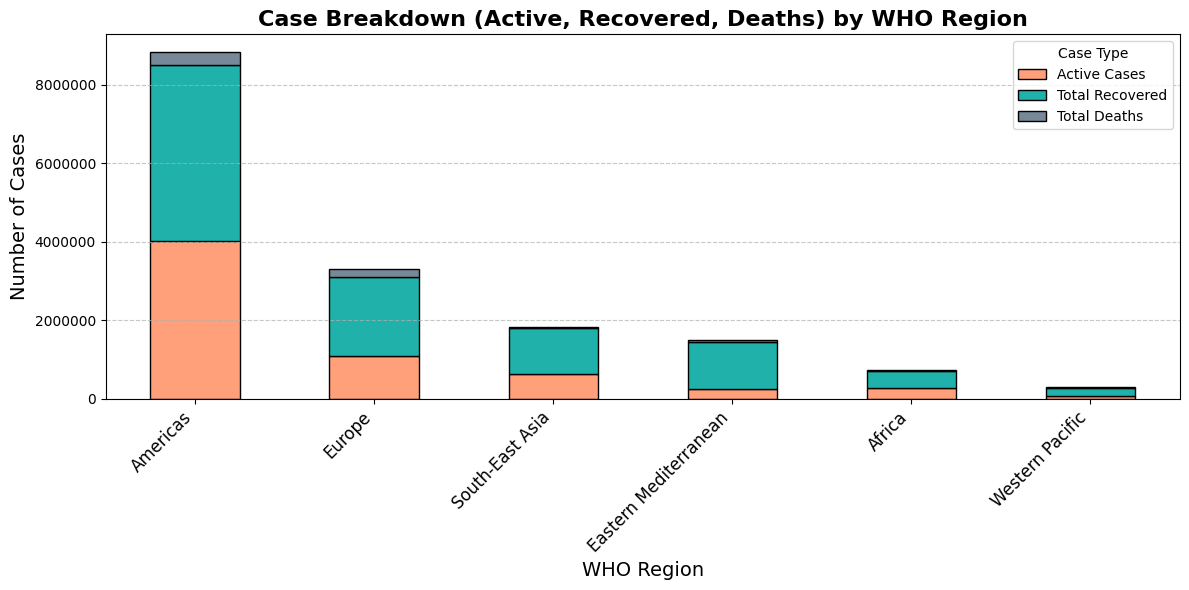

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
who_pd[["Active Cases", "Total Recovered", "Total Deaths"]].plot(
    kind='bar', stacked=True, ax=ax, color=['#FFA07A', '#20B2AA', '#778899'], edgecolor='black'
)

plt.title("Case Breakdown (Active, Recovered, Deaths) by WHO Region", fontsize=16, fontweight='bold')
plt.xlabel("WHO Region", fontsize=14)
plt.ylabel("Number of Cases", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Disabled scientific notation
plt.legend(title="Case Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()